## Boolean analysis

Here we are trying to apply Boolean Fourier Analysis to the sign structure. The main reference is:

- Ryan O'Donnel. [Analysis of Boolean Functions.](http://www.cs.cmu.edu/~odonnell/papers/Analysis-of-Boolean-Functions-by-Ryan-ODonnell.pdf).

Caveat: our space is not a space of boolean functions defined on $\{0,1\}^n$, as we are working in the sector of zero magnetization (equal number of spins up and down). So, the set of parity functions that is used as a basis in BFA is *not* an orthonormal basis of the space of boolean functions defined in the sector of zero magnetization.

Possible workarounds:

- It is possible to consider the full eigenstate $\{0, 1\}^n \to \mathbb R$, not only the sign structure. Products are still form the orthonormal basis in this space.
- It is possible to consider the sign structure with zeroes: $\{0, 1\}^n \to \{-1, 0, 1\}$.

In [69]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

<IPython.core.display.Javascript object>

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
from tqdm.auto import tqdm

from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

%matplotlib inline

/home/ischurov/.conda/envs/latsym/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=True,
    spin_inversion=1,
)
system.get_ground_state()
df = system.get_df_ground_state(canonical_basis=True)

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337


In [20]:
df

,basis_state,ground_state_coeff,amplitude
0,255,0.000752,0.000752
1,4010,0.000752,0.000752
2,13071,0.000752,0.000752
3,26172,0.000752,0.000752
4,39363,0.000752,0.000752
...,...,...,...
12865,42342,0.030783,0.030783
12866,43571,0.030783,0.030783
12867,50085,0.030783,0.030783
12868,23142,0.287392,0.287392


In [17]:
masks = np.arange(2 ** system.number_spins).reshape(1, -1).astype('uint64')

In [21]:
masked = df['basis_state'].values.reshape(-1, 1) & masks

In [23]:
masked.ndim

2

In [82]:
def parity_of_1s(x, n):
    parity = np.zeros_like(x, dtype="uint8")
    x = x.copy()
    for i in tqdm(range(n)):
        parity ^= x & 1
        x >>= 1
    return parity

In [83]:
assert (
    np.isclose(
        parity_of_1s(np.array([[1, 2, 3], [4, 5, 6]], dtype="uint64"), 3),
        np.array([[1, 1, 0], [1, 0, 0]], dtype="uint64"),
    )
).all()

100%|██████████| 3/3 [00:00<00:00, 18558.87it/s]


In [84]:
parities = parity_of_1s(masked, system.number_spins)

100%|██████████| 16/16 [04:38<00:00, 17.38s/it]


array([[0, 1, 1, ..., 1, 1, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 1, 1, ..., 1, 1, 0],
       ...,
       [0, 1, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 1, 0]], dtype=uint8)

In [91]:
parities_pm = parities.astype("int8") * 2 - 1

In [95]:
df["ground_state_coeff"]

0        0.000752
1        0.000752
2        0.000752
3        0.000752
4        0.000752
           ...   
12865    0.030783
12866    0.030783
12867    0.030783
12868    0.287392
12869    0.287392
Name: ground_state_coeff, Length: 12870, dtype: float64

In [104]:
parities_pm.shape

(12870, 65536)

In [111]:
fourier_coeffs = (
    np.sign(df["ground_state_coeff"]).values.reshape(-1, 1) * parities_pm
).mean(axis=0)

In [113]:
np.argmax(np.abs(fourier_coeffs))

23142

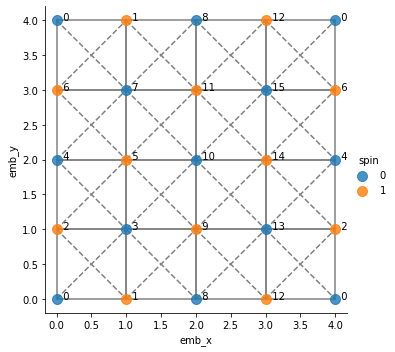

In [118]:
system.lat.plot(
    spins=make_unpacked_configurations(23142, number_spins=system.number_spins)
)

In [126]:
df_fourier_coeffs = pd.DataFrame(
    dict(
        mask=list(
            make_unpacked_configurations(
                masks[0], number_spins=system.number_spins
            )
        ),
        coeff=fourier_coeffs,
    )
)

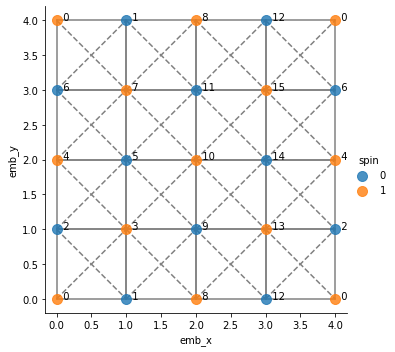

In [135]:
system.lat.plot(
    spins=df_fourier_coeffs.assign(abs_coeff=lambda x: np.abs(x["coeff"]))
    .sort_values("abs_coeff", ascending=False)
    .iloc[0]["mask"]
)

Okay, that's the Marshall's sign rule. Seems to be working.